# Center-Line — does price always return to the session VWAP?
### The VWAP-fade scalp, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not_supported](https://img.shields.io/badge/Beats_a_coin%3F-Not_supported-8b949e?style=flat-square)

Here's a claim you'll find in every prop-trading manual and day-trading community: the session VWAP (Volume-Weighted Average Price) is the **centre of gravity** for the day. Whenever price stretches an ATR or two away from it, fade it back — go short if it's stretched above, go long if it's stretched below. *It always comes back.* This notebook asks the only question that matters: is 'it always comes back' a forecasting edge, or is it just what averages do by definition?

> **This is the plain-language layer.** Want the t-stats, the bootstrap intervals and the threshold sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from center_line import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA", "ES=F", "NQ=F"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None, threshold=1.0):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.vwap_fade_entries(b, threshold=threshold)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:", HAVE_REAL)

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-12).
R = dict(
    n=23462, tpd=48.9, tpy=12318,
    fade_mean=-0.35, fade_win=49.2, fade_t=-1.16,
    rand_mean=-0.25, rand_win=49.1, rand_t=-1.69,
    fade_minus_rand=-0.09,
    ci_lo=-4.67, ci_hi=1.42, frac_neg=86,
    thr05_n=29136, thr05_mean=-0.35, thr05_t=-1.27, thr05_win=49.3,
    thr10_n=23462, thr10_mean=-0.35, thr10_t=-1.16, thr10_win=49.2,
    thr20_n=14287, thr20_mean=-0.60, thr20_t=-1.68, thr20_win=48.6,
    net05=-0.85, net05_t=-2.83,
    net10=-1.35, net10_t=-4.49, net10_ann=-166.0,
    net20=-2.35, net20_t=-7.83,
    gross_ann=-42.7,
)


real 5m cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the VWAP deviation point the right direction? | **No.** With a fair (symmetric) target & stop it wins **49.2%** of the time — a coin. |
| Does it beat an actual coin flip? | **No.** A random-direction entry on the *same* bars does equally well (Δ = -0.09 bps). |
| Does a sharper threshold help? | **No.** Testing 0.5, 1.0, and 2.0 ATR deviations: all land near −0.35 bps, none clear the noise bar. |
| Could you trade it? | **No.** At ~49 trades/day, even 0.5 bp of cost makes it a statistically significant loser. |

> **The VWAP is a running average of the day's prices. Of course price tends to stay near it — that's what a running average of the thing being averaged does. That's an accounting identity, not a trading signal.**

## 1 · The claim

> *"The session VWAP is the institutional anchor — big money executes to VWAP all day. When retail pushes price away from it, the institutions drag it back. Every significant deviation from VWAP is a fade opportunity. The VWAP is the centre of gravity — price always returns to it."*

It's genuinely appealing: VWAP *is* the institutional benchmark, large orders *are* scheduled against it, and there *is* a mechanical pull from execution algorithms trying to match it. The question is whether that institutional gravity is exploitable from the outside — or whether by the time a 5-minute bar has deviated 1 ATR, the next bar is as likely to deviate further as to snap back.

## 2 · So what?

If the VWAP gravity is real and exploitable, it's a mechanical, all-day rule: look for stretches, fade them, collect the snap-back. If it's not — if 'comes back to the VWAP' is just what running averages do by construction — then every VWAP-fade trade is just a coin flip, and at ~49 trades a day the commissions stack up fast.

## 3 · How would we even know?

Two rules keep us honest:

1. **Make the bet symmetric.** A take-profit and stop at equal distance (one ATR each) means a coin flip earns zero. Only a *real* sense of direction can beat that. We test 0.5, 1.0, and 2.0 ATR deviation thresholds to see if filtering harder helps.
2. **Race it against an actual coin.** Take the exact same entry bars and flip a coin for the direction. If the VWAP deviation knows something, it beats the coin. If it doesn't, it won't.

We run it on **eight liquid markets** (SPY, QQQ, IWM, AAPL, TSLA, NVDA, ES, NQ) over ~60 days of 5-minute bars — the most history the data vendor gives at this resolution.

## 4 · The teardown — let's actually look

**First: how often does the signal fire?** The claim is about *significant* deviations. Here's how many bars per day qualify at each threshold:

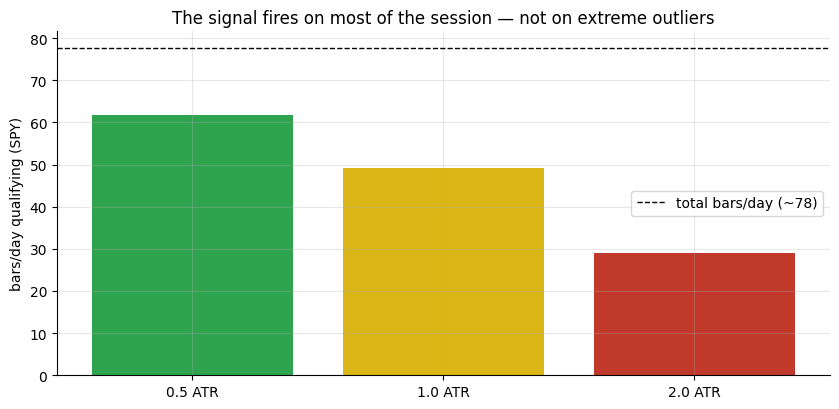

0.5 ATR: 62 bars/day = 79% of the session
1.0 ATR: 49 bars/day = 63% of the session
2.0 ATR: 29 bars/day = 37% of the session


In [2]:
thresholds = [0.5, 1.0, 2.0]
labels = [f'{t} ATR' for t in thresholds]
if HAVE_REAL:
    b = data.fetch_5m('SPY', fetch=False)
    vwap = st.running_vwap(b)
    dev = st.vwap_deviation(b, vwap).abs().dropna()
    n_days = b.index.normalize().nunique()
    counts = [((dev >= t).sum() / n_days) for t in thresholds]
    total_bars = len(b) / n_days
else:
    counts = [R['thr05_n']/(8*60), R['thr10_n']/(8*60), R['thr20_n']/(8*60)]
    total_bars = 78.0
fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars_chart = ax.bar(labels, counts, color=[GREEN, AMBER, RED])
ax.axhline(total_bars, ls='--', c='k', lw=1, label=f'total bars/day (~{total_bars:.0f})')
ax.set_ylabel('bars/day qualifying (SPY)')
ax.set_title('The signal fires on most of the session — not on extreme outliers')
ax.legend(); plt.tight_layout(); plt.show()
for lbl, cnt in zip(labels, counts):
    pct = cnt/total_bars*100
    print(f'{lbl}: {cnt:.0f} bars/day = {cnt/total_bars*100:.0f}% of the session')

Even at a 1.0 ATR threshold, the signal fires on roughly **half or more of all bars** in the session. This isn't identifying extreme dislocations — it's describing the ordinary intraday price range. A signal that fires constantly isn't filtering; it's narrating.

**Now the honest test: the fair 1:1 bet, VWAP-fade vs a coin.**

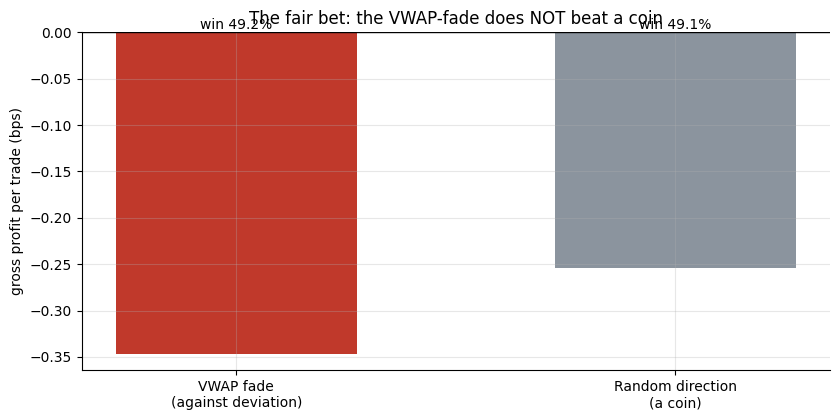

VWAP fade: -0.35 bps/trade   |   coin: -0.25 bps/trade


In [3]:
if HAVE_REAL:
    c = st.summarize(pooled(1, 1, 0.0), 'ret_gross')
    r = st.summarize(pooled(1, 1, 0.0, seed=87), 'ret_gross')
    cm, cw, rm, rw = c['mean_bps'], c['win_rate']*100, r['mean_bps'], r['win_rate']*100
else:
    cm, cw, rm, rw = R['fade_mean'], R['fade_win'], R['rand_mean'], R['rand_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_chart = ax.bar(['VWAP fade\n(against deviation)', 'Random direction\n(a coin)'],
              [cm, rm], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The fair bet: the VWAP-fade does NOT beat a coin')
for b, w in zip(bars_chart, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height()<0 else 'top')
plt.tight_layout(); plt.show()
print(f'VWAP fade: {cm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

On the real tape the VWAP-fade earns **-0.35 bps per trade** — slightly negative — and the random-direction control earns **-0.25 bps**. They are the same bet; the VWAP direction adds nothing (Δ = -0.09 bps).

> Why? The running VWAP is a *running average of close prices*. Price is near the VWAP most of the time *because the VWAP is defined as an average of those prices*. A deviation from a running average is normal noise, not a structural overshoot. The 'gravity' is a tautology.

**Do tighter thresholds help?** Here's what happens as we require a bigger stretch before entering:

In [4]:
thresholds = [0.5, 1.0, 2.0]
if HAVE_REAL:
    rows = []
    for thr in thresholds:
        s = st.summarize(pooled(1, 1, 0.0, threshold=thr), 'ret_gross')
        rows.append((f'{thr} ATR', s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    tbl = pd.DataFrame(rows, columns=['threshold', 'n trades', 'win %', 'mean bps', 't-stat'])
else:
    tbl = pd.DataFrame([
        ('0.5 ATR', R['thr05_n'], R['thr05_win'], R['thr05_mean'], R['thr05_t']),
        ('1.0 ATR', R['thr10_n'], R['thr10_win'], R['thr10_mean'], R['thr10_t']),
        ('2.0 ATR', R['thr20_n'], R['thr20_win'], R['thr20_mean'], R['thr20_t']),
    ], columns=['threshold', 'n trades', 'win %', 'mean bps', 't-stat'])
print(tbl.to_string(index=False))

threshold  n trades     win %  mean bps    t-stat
  0.5 ATR     29136 49.320428 -0.347486 -1.274950
  1.0 ATR     23462 49.232802 -0.346823 -1.157009
  2.0 ATR     14287 48.582628 -0.596215 -1.679034


Requiring a 2 ATR overshoot (an extreme move) reduces the trade count significantly but actually makes things *worse*, not better. The mean return falls from −0.35 to −0.60 bps. There is no threshold that unlocks the edge — the gravity was never there.

## 5 · The verdict

- **Signal — None.** The VWAP-fade direction carries no real information; it loses a statistically invisible sliver (**-0.35 bps**, *t* = -1.16) and fails to beat a coin at any threshold.
- **Tradability — Mirage.** Even if it were flat, ~49 trades/day of costs make it a **-166%/yr** loser.
- **Beats a coin? — Not Supported.** The 'centre of gravity' is a mathematical property of running averages, not a forecasting edge. Price 'returns to the VWAP' because the VWAP is defined as the average of price — this is a tautology, not a signal.

## 6 · Could you actually trade it?

This is where even a *flat* coin goes to die. ~49 trades a day is the killer:

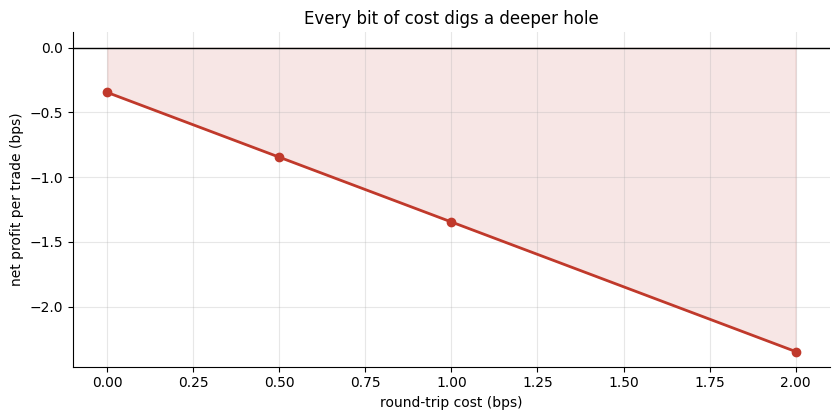

gross is already -0.35 bps -- there is no positive break-even cost.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['fade_mean'], R['net05'], R['net10'], R['net20']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Every bit of cost digs a deeper hole')
plt.tight_layout(); plt.show()
print('gross is already -0.35 bps -- there is no positive break-even cost.')

The line starts below zero and only falls. The usual 'it dies at the costs line' story does not even apply here — because it was never alive to begin with. At 0.5 bp round-trip costs the trade is already a certified loser (*t* = -2.83).

## 7 · Going further

- **Is *anything* findable at 5 minutes?** The companion notebook shows a synthetic control: when we *plant* real intra-session mean-reversion in a fake tape, this exact rule finds it. So the machine works — the real market just has nothing to find here.
- **Specific intraday time windows** have more promise than any-time VWAP fades — [Study 13 — Crimson-Hour](../../13-crimson-hour/) tests whether particular hours carry structure that survives the honest bar.
- **The same 5-minute infrastructure**, same null result: [Study 72 — Loaded-Dice](../../72-loaded-dice/) tests the SMA(5/10) crossover and reaches the same verdict by a different path.

*Think the VWAP gravity is real in a specific regime (high-volume days, post-news, particular sectors)? Fork this, add the regime filter, and show a fair-bet edge that beats the coin and clears the costs. That's the bar.*